# Explore the catalog using interactive plotly graphs

In [45]:
import json
import numpy as np
import pandas as pd

import sys, os
from io import StringIO

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR

file_path = MAIN_CATALOG

In [46]:
# === Load JSON ===
def read_json_file(file_path): 
    try: 
        with open(file_path, "r") as f: data = json.load(f) 
        return data 
    except Exception as e: 
        print(f"Error reading file: {e}")
        return None

def read_json_file_topd(file_path, as_dataframe=True):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        # If JSON is a dict of systems → convert to list
        if isinstance(data, dict):
            data = list(data.values())

        if as_dataframe:
            return pd.DataFrame(data)

        return data

    except Exception as e:
        print(f"Error reading file: {e}")
        return None


# ==  Function to easily extract some of the cols ==    
def extract_array(data, key):
    """Extracts a given key from each system and returns a list."""
    try:
        values = [entry.get(key, None) for entry in data]
        return values  # Return list, not np.array - let to_triplet_array handle conversion
    except Exception as e:
        print(f"Error extracting {key}: {e}")
        return None

def extract_multiple(data, keys):
    return {key: extract_array(data, key) for key in keys}

def to_triplet_array(arr):
    """
    Convert array-like of triplets to (N,3) float array.
    Invalid entries become [nan, nan, nan].
    """
    if arr is None:
        return np.array([])
    
    out = []
    for row in arr:
        if isinstance(row, (list, tuple, np.ndarray)) and len(row) == 3:
            out.append(row)
        else:
            out.append([np.nan, np.nan, np.nan])
    return np.array(out, dtype=float)


In [47]:
pd_catalog_data = read_json_file_topd(file_path)
print(pd_catalog_data.keys()    )
display(pd_catalog_data[pd_catalog_data["system_class"] == "Contact binary"])


Index(['System Name', 'Type1', 'Type2', 'Detection Method', 'Reference',
       'Notes', 'RA', 'Dec', 'Period', 'Eccentricity', 'M1', 'M1_sin3i', 'M2',
       'M2_sin3i', 'q', 'Mass Function', 'source_file', 'evol_type_1',
       'evol_type_2', 'obs_type_1', 'obs_type_2', 'system_class', 'Simbad'],
      dtype='object')


,System Name,Type1,Type2,Detection Method,Reference,Notes,RA,Dec,Period,Eccentricity,...,M2_sin3i,q,Mass Function,source_file,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class,Simbad
148,LSS 3074,"O6-7:(f):, Contact","O4 f +, Contact","[RV, EB]",2017A&A...601A.133R,Gaia DR3 5868409430865830912,"[0.0097, 201.74924, 0.0097]","[0.0118, -62.03038, 0.0118]","[0.0006, 2.1852, 0.0006]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.86, 0.04]","[None, None, None]",contact1.h5,MS,MS,O6-7:(f):,O4 f +,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
149,MY Cam,"O4.5-6V, Contact","O6V, Contact","[RV, EB]",2014A&A...572A.110,Gaia DR3 469715181320008960,"[0.0236, 59.82622, 0.0236]","[0.0207, 57.23716, 0.0207]","[0.0, 1.17545, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.84, 0.04]","[None, None, None]",contact1.h5,MS,MS,O4.5-6V,O6V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
150,OGLE SMC-SC10 108086,"O9V, Contact","O9.5-B0V, Contact","[RV, EB]",2005MNRAS.357..304H,"Gaia DR3 4690510870334496896, SMC","[0.0242, 16.37751, 0.0242]","[0.0219, -72.0227, 0.0219]","[None, 0.8831, None]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.06, 0.85, 0.06]","[None, None, None]",contact1.h5,MS,MS,O9V,O9.5-B0V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
151,TU Mus,"O7V, Contact","O8V, Contact","[RV, EB, IUE]",2008ApJ...681..554P,"Gaia DR3 5237207155697930496, HD 100213","[0.0188, 172.79544, 0.0188]","[0.0195, -65.74225, 0.0195]","[0.0, 1.38728, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.009, 0.623, 0.009]","[None, None, None]",contact1.h5,MS,MS,O7V,O8V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
152,V382 Cyg,"O6.5V((f)), Contact","O6V((f)), Contact","[RV, EB]",2017A&A...607A..82M,"Gaia DR3 2057530097777247744, HD 228854","[0.0183, 304.69673, 0.0183]","[0.024, 36.34055, 0.024]","[1e-05, 1.88555, 1e-05]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.005, 0.727, 0.005]","[None, None, None]",contact1.h5,MS,MS,O6.5V((f)),O6V((f)),Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
153,VFTS 352,"O4.5 V(n)((fc))z, Contact","O5.5 V(n)((fc))z, Contact","[RV, EB]",2015ApJ...812..102A,"Gaia DR3 4657678216202797440, LMC","[0.017, 84.61859, 0.017]","[0.0195, -69.18864, 0.0195]","[0.0, 1.12415, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.1, 0.99, 0.1]","[None, None, None]",contact1.h5,MS,MS,O4.5 V(n)((fc))z,O5.5 V(n)((fc))z,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
154,CT Tau,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,"Gaia DR3 3430795519289951744,HD 249751","[0.021, 89.70881, 0.021]","[0.0182, 27.0783, 0.0182]","[0.0, 0.66683, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.983, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
155,GU Mon,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,Gaia DR3 3125506151511957120,"[0.0172, 101.19525, 0.0172]","[0.0172, 0.22175, 0.0172]","[0.0, 0.89665, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.976, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
156,SV Cen,"B, Contact?","B, Contact?","[RV, EB]",1992AJ....103..573R,"Gaia DR3 5335388664983921024, HD 102552,Pdot s...","[0.0235, 176.98836, 0.0235]","[0.0222, -60.56604, 0.0222]","[0.001, 1.658, 0.001]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.002, 0.71, 0.002]","[None, None, None]",contact1.h5,MS,MS,B,B,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
157,V606 Cen,"B0.5V, Contact","B2V, Contact","[RV, EB]","1999A&A...345..531L,2022ApJ...924...30L","Gaia DR3 5869546428991037312, HD 115937; tripl...","[0.0092, 200.40113, 0.0092]","[0.011, -60.52077, 0.011]","[0.0, 1.4951, 0.0]","[0.07, 0.33, 0.07]",...,"[None, None, None]","[0.0007, 0.5484, 0.0007]","[None, None, None]",contact1.h5,MS,MS,B0.5V,B2V,Contact binary,

In [48]:
pd_catalog_data.keys()

Index(['System Name', 'Type1', 'Type2', 'Detection Method', 'Reference',
       'Notes', 'RA', 'Dec', 'Period', 'Eccentricity', 'M1', 'M1_sin3i', 'M2',
       'M2_sin3i', 'q', 'Mass Function', 'source_file', 'evol_type_1',
       'evol_type_2', 'obs_type_1', 'obs_type_2', 'system_class', 'Simbad'],
      dtype='object')

In [49]:
display(pd_catalog_data[['M1', 'M2', 'evol_type_1','evol_type_2', 'obs_type_1', 'obs_type_2',  'system_class',  ]])

M1 = to_triplet_array(pd_catalog_data['M1'] )
print(M1[:,1])  # Extract median M1 values
print(pd_catalog_data['M1'][:]) # Extract median M1 values

,M1,M2,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class
0,"[None, None, None]","[None, None, None]",MS,WD,None,None,Blue straggler binary
1,"[None, None, None]","[None, None, None]",MS,WD,None,None,Blue straggler binary
2,"[None, None, None]","[None, None, None]",MS,WD,None,None,Blue straggler binary
3,"[None, None, None]","[None, None, None]",MS,WD,None,None,Blue straggler binary
4,"[None, None, None]","[None, None, None]",MS,WD,None,None,Blue straggler binary
...,...,...,...,...,...,...,...
4446,"[1.6199999999999999, 1.69, 1.76]","[0.24, 0.31, 0.38]",MS,WD,None,pre-He WD,EL CVn
4447,"[1.3599999999999999, 1.4, 1.44]","[0.22, 0.26, 0.3]",MS,WD,None,pre-He WD,EL CVn
4448,"[1.52, 1.6, 1.6800000000000002]","[0.11, 0.16, 0.21000000000000002]",MS,WD,None,pre-He WD,EL CVn
4449,"[1.5899999999999999, 1.65, 1.71]","[0.24999999999999997, 0.29, 0.32999999999999996]",MS,WD,None,pre-He WD,EL CVn


[ nan  nan  nan ... 1.6  1.65 1.57]
0                     [None, None, None]
1                     [None, None, None]
2                     [None, None, None]
3                     [None, None, None]
4                     [None, None, None]
                      ...               
4446    [1.6199999999999999, 1.69, 1.76]
4447     [1.3599999999999999, 1.4, 1.44]
4448     [1.52, 1.6, 1.6800000000000002]
4449    [1.5899999999999999, 1.65, 1.71]
4450                  [1.52, 1.57, 1.62]
Name: M1, Length: 4451, dtype: object


In [50]:
# === Interactive Plotting with Plotly ===
def plotly_vars(x_key, y_key, df, logx=False, logy=False, color_by="system_class", color_map=None):
    """
    Create interactive plotly scatter plot with error bars.
    
    Parameters:
        x_key, y_key: str
            Column names for x and y axes (e.g., 'Period', 'M1', 'Eccentricity')
        df: pandas DataFrame
            DataFrame with the catalog data (e.g., pd_catalog_data)
        logx, logy: bool
            Whether to use logarithmic axes
        color_by: str
            Column to color points by (e.g., 'system_class', 'evol_type_1', 'obs_type_1')
        color_map: dict (optional)
            Custom color mapping {category: color_hex}. If None, uses default palette.
    
    Returns:
        Plotly figure object
    """
    # Extract x and y data with uncertainties
    X_arr = to_triplet_array(df[x_key])
    Y_arr = to_triplet_array(df[y_key])

    # Get color categories
    color_categories = df[color_by].fillna("Unknown")

    # Filter valid data (require finite triplets); enforce positive for log axes
    valid_mask = np.isfinite(X_arr).all(axis=1) & np.isfinite(Y_arr).all(axis=1)
    if logx:
        valid_mask &= X_arr[:, 1] > 0
    if logy:
        valid_mask &= Y_arr[:, 1] > 0

    # Apply mask
    X_arr = X_arr[valid_mask]
    Y_arr = Y_arr[valid_mask]
    df_valid = df[valid_mask].copy()
    color_categories = color_categories[valid_mask]

    # Extract central values and uncertainties
    x = X_arr[:, 1]
    x_lower = X_arr[:, 0]
    x_upper = X_arr[:, 2]

    y = Y_arr[:, 1]
    y_lower = Y_arr[:, 0]
    y_upper = Y_arr[:, 2]

    # Calculate non-negative error bar sizes
    xerr_minus = np.maximum(x - x_lower, 0)
    xerr_plus = np.maximum(x_upper - x, 0)
    yerr_minus = np.maximum(y - y_lower, 0)
    yerr_plus = np.maximum(y_upper - y, 0)

    # Create color mapping if not provided
    if color_map is None:
        unique_categories = sorted(color_categories.unique())
        palette = px.colors.qualitative.Dark24
        color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_categories)}

    # Create plotting DataFrame
    plot_df = pd.DataFrame({
        x_key: x,
        y_key: y,
        'xerr_minus': xerr_minus,
        'xerr_plus': xerr_plus,
        'yerr_minus': yerr_minus,
        'yerr_plus': yerr_plus,
        'color_category': color_categories.values,
        'System Name': df_valid['System Name'].fillna("Unknown"),
        'Type1': df_valid.get('Type1', '').fillna(''),
        'Type2': df_valid.get('Type2', '').fillna(''),
        'evol_type_1': df_valid.get('evol_type_1', '').fillna(''),
        'evol_type_2': df_valid.get('evol_type_2', '').fillna(''),
        'obs_type_1': df_valid.get('obs_type_1', '').fillna(''),
        'obs_type_2': df_valid.get('obs_type_2', '').fillna(''),
        'system_class': df_valid.get('system_class', '').fillna('Unknown'),
    })

    # Create figure
    fig = px.scatter(
        plot_df,
        x=x_key,
        y=y_key,
        color='color_category',
        color_discrete_map=color_map,
        hover_data={
            x_key: ':.3f',
            y_key: ':.3f',
            'System Name': True,
            'Type1': True,
            'Type2': True,
            'evol_type_1': True,
            'evol_type_2': True,
            'obs_type_1': True,
            'obs_type_2': True,
            'system_class': True,
            'color_category': False
        },
        # error_x='xerr_plus',
        # error_x_minus='xerr_minus',
        # error_y='yerr_plus',
        # error_y_minus='yerr_minus',
        labels={x_key: x_key, y_key: y_key, 'color_category': color_by}
    )

    # Update layout
    fig.update_layout(
        width=1200,
        height=900,
        xaxis_title=x_key,
        yaxis_title=y_key,
        xaxis_title_font=dict(size=18),
        yaxis_title_font=dict(size=18),
        legend=dict(font=dict(size=14), title=dict(text=color_by, font=dict(size=16))),
    )

    fig.update_traces(marker=dict(size=6))
    fig.update_yaxes(tickfont=dict(size=14))
    fig.update_xaxes(tickfont=dict(size=14))

    # Apply log scales if requested
    if logx:
        fig.update_xaxes(type="log")
    if logy:
        fig.update_yaxes(type="log")

    return fig


In [51]:
# custom color mapping
custom_colors = {
    'Hot subdwarf': '#cc5159',
    'Stripped star': '#3dceb4',
    'WR binary': '#5987d6',
    'Algol': '#f39c12',
    'Contact binary': '#9b59b6',
    'WD': '#95a5a6',
    'Barium star': '#e74c3c',
    'Post-CE': '#2ecc71',
    'NS': '#3498db',
    'BH': '#1abc9c',
}

fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='system_class', color_map=custom_colors)
fig.show()


In [52]:
custom_colors = {
    'WD':'#bfbfbf',
    'He-star':'#3eb6c4',
    'MS':'#469955',
    'BH':'#161616',
    'NS':'#a77cc9',
    'AGB':'#e2913b',
    'HG':'#e2da3b',
    'RGB': '#cc5159'
}
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='evol_type_2', color_map=custom_colors)

fig.show()



In [53]:
custom_colors = {
    'WD':'#bfbfbf',
    'He-star':'#3eb6c4',
    'MS':'#469955',
    'BH':'#161616',
    'NS':'#a77cc9',
    'AGB':'#e2913b',
    'HG':'#e2da3b',
    'RGB': '#cc5159'
}
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, logy=False, 
                  color_by='evol_type_2', color_map=custom_colors)

fig.show()



In [54]:
pd_catalog_data['evol_type_2'].dropna().unique()

array(['WD', 'He-star', 'MS', 'BH', 'NS', 'AGB', 'HG', 'RGB'],
      dtype=object)

In [55]:
P = to_triplet_array(pd_catalog_data['Period'] )
print(len(pd_catalog_data[P[:,1] < 0.001 ]))

0


In [56]:
display(pd_catalog_data[pd_catalog_data['system_class'] == 'Contact binary' ])


,System Name,Type1,Type2,Detection Method,Reference,Notes,RA,Dec,Period,Eccentricity,...,M2_sin3i,q,Mass Function,source_file,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class,Simbad
148,LSS 3074,"O6-7:(f):, Contact","O4 f +, Contact","[RV, EB]",2017A&A...601A.133R,Gaia DR3 5868409430865830912,"[0.0097, 201.74924, 0.0097]","[0.0118, -62.03038, 0.0118]","[0.0006, 2.1852, 0.0006]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.86, 0.04]","[None, None, None]",contact1.h5,MS,MS,O6-7:(f):,O4 f +,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
149,MY Cam,"O4.5-6V, Contact","O6V, Contact","[RV, EB]",2014A&A...572A.110,Gaia DR3 469715181320008960,"[0.0236, 59.82622, 0.0236]","[0.0207, 57.23716, 0.0207]","[0.0, 1.17545, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.04, 0.84, 0.04]","[None, None, None]",contact1.h5,MS,MS,O4.5-6V,O6V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
150,OGLE SMC-SC10 108086,"O9V, Contact","O9.5-B0V, Contact","[RV, EB]",2005MNRAS.357..304H,"Gaia DR3 4690510870334496896, SMC","[0.0242, 16.37751, 0.0242]","[0.0219, -72.0227, 0.0219]","[None, 0.8831, None]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.06, 0.85, 0.06]","[None, None, None]",contact1.h5,MS,MS,O9V,O9.5-B0V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
151,TU Mus,"O7V, Contact","O8V, Contact","[RV, EB, IUE]",2008ApJ...681..554P,"Gaia DR3 5237207155697930496, HD 100213","[0.0188, 172.79544, 0.0188]","[0.0195, -65.74225, 0.0195]","[0.0, 1.38728, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.009, 0.623, 0.009]","[None, None, None]",contact1.h5,MS,MS,O7V,O8V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
152,V382 Cyg,"O6.5V((f)), Contact","O6V((f)), Contact","[RV, EB]",2017A&A...607A..82M,"Gaia DR3 2057530097777247744, HD 228854","[0.0183, 304.69673, 0.0183]","[0.024, 36.34055, 0.024]","[1e-05, 1.88555, 1e-05]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.005, 0.727, 0.005]","[None, None, None]",contact1.h5,MS,MS,O6.5V((f)),O6V((f)),Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
153,VFTS 352,"O4.5 V(n)((fc))z, Contact","O5.5 V(n)((fc))z, Contact","[RV, EB]",2015ApJ...812..102A,"Gaia DR3 4657678216202797440, LMC","[0.017, 84.61859, 0.017]","[0.0195, -69.18864, 0.0195]","[0.0, 1.12415, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.1, 0.99, 0.1]","[None, None, None]",contact1.h5,MS,MS,O4.5 V(n)((fc))z,O5.5 V(n)((fc))z,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
154,CT Tau,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,"Gaia DR3 3430795519289951744,HD 249751","[0.021, 89.70881, 0.021]","[0.0182, 27.0783, 0.0182]","[0.0, 0.66683, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.983, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
155,GU Mon,"B1V, Contact","B1V, Contact","[RV, EB]",2019AJ....157..111Y,Gaia DR3 3125506151511957120,"[0.0172, 101.19525, 0.0172]","[0.0172, 0.22175, 0.0172]","[0.0, 0.89665, 0.0]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.003, 0.976, 0.003]","[None, None, None]",contact1.h5,MS,MS,B1V,B1V,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
156,SV Cen,"B, Contact?","B, Contact?","[RV, EB]",1992AJ....103..573R,"Gaia DR3 5335388664983921024, HD 102552,Pdot s...","[0.0235, 176.98836, 0.0235]","[0.0222, -60.56604, 0.0222]","[0.001, 1.658, 0.001]","[0.0, 0.0, 0.0]",...,"[None, None, None]","[0.002, 0.71, 0.002]","[None, None, None]",contact1.h5,MS,MS,B,B,Contact binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
157,V606 Cen,"B0.5V, Contact","B2V, Contact","[RV, EB]","1999A&A...345..531L,2022ApJ...924...30L","Gaia DR3 5869546428991037312, HD 115937; tripl...","[0.0092, 200.40113, 0.0092]","[0.011, -60.52077, 0.011]","[0.0, 1.4951, 0.0]","[0.07, 0.33, 0.07]",...,"[None, None, None]","[0.0007, 0.5484, 0.0007]","[None, None, None]",contact1.h5,MS,MS,B0.5V,B2V,Contact binary,

In [57]:
# Unique references for contact binaries
unique_refs = np.unique(pd_catalog_data['Reference'][pd_catalog_data['system_class'] == 'Stripped star' ])
print([ref[0] for ref in unique_refs])

['2020A&A...639L...6S', '2022MNRAS.511L..24E', '2022NatAs...6.1414I', '2023A&A...674L..12R', '2023MNRAS.518.3541G', '2023MNRAS.525.5121V', '2024A&A...692A..90R']


In [58]:
hot_subdwarfs = pd_catalog_data[pd_catalog_data['system_class'] == 'Hot subdwarf']
stripped_stars = pd_catalog_data[pd_catalog_data['system_class'] == 'Stripped star' ]
WR_binaries = pd_catalog_data[pd_catalog_data['system_class'] == 'WR binary' ]

# display(hot_subdwarfs)
# display(stripped_stars)
display(WR_binaries)

,System Name,Type1,Type2,Detection Method,Reference,Notes,RA,Dec,Period,Eccentricity,...,M2_sin3i,q,Mass Function,source_file,evol_type_1,evol_type_2,obs_type_1,obs_type_2,system_class,Simbad
33,BAT99 19,O6 V,WR-WN4,RV,"[2003MNRAS.338.1025F, 2019A&A...627A.151S]",,"[1e-05, 77.41841, 1e-05]","[0.0, -68.89021, 0.0]","[0.002, 17.994, 0.002]","[0.014, 0.02, 0.014]",...,"[2.6, 22.1, 2.6]","[0.026, 0.558, 0.026]","[None, None, None]",WRs_LMC.h5,MS,He-star,O6 V,WR-WN4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
34,BAT99 28,O5 V,WR-WC6,RV,[1990ApJ...348..232M],,"[3e-05, 79.81813, 3e-05]","[1e-05, -69.65556, 1e-05]","[None, 14.926, None]","[0.05, 0.16, 0.05]",...,"[2.7, 10.2, 2.7]","[0.026, 0.558, 0.026]","[None, None, None]",WRs_LMC.h5,MS,He-star,O5 V,WR-WC6,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
35,BAT99 29,B1.5 V,WR-WN3,RV,[2003MNRAS.338.1025F],Mass function computed with respect to M2,"[0.0001, 80.18638, 0.0001]","[4e-05, -65.47235, 4e-05]","[0.0003, 2.2016, 0.0003]","[0.13, 0.16, 0.13]",...,"[None, None, None]","[None, None, None]","[0.019, 0.045, 0.019]",WRs_LMC.h5,MS,He-star,B1.5 V,WR-WN3,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
36,BAT99 38,O-uncertain,WR-WC4,RV,[1990ApJ...348..232M],Mass function computed with respect to M2,"[2e-05, 81.51652, 2e-05]","[1e-05, -67.49919, 1e-05]","[None, 3.03269, None]","[None, 0.0, None]",...,"[None, None, None]","[None, None, None]","[1.2, 6.5, 1.2]",WRs_LMC.h5,MS,He-star,O-uncertain,WR-WC4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
37,BAT99 39,O6 V,WR-WC4,RV,[1990ApJ...348..232M],,"[5e-05, 81.62608, 5e-05]","[1e-05, -68.84097, 1e-05]","[None, 3.03269, None]","[None, 0.0, None]",...,"[0.2, 0.6, 0.2]","[0.032, 0.167, 0.032]","[None, None, None]",WRs_LMC.h5,MS,He-star,O6 V,WR-WC4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
38,BAT99 43,O9 V,WR-WN3,RV,[2003MNRAS.338.1025F],Mass function computed with respect to M2,"[2e-05, 81.90704, 2e-05]","[1e-05, -70.60148, 1e-05]","[0.0002, 2.816, 0.0002]","[0.05, 0.07, 0.05]",...,"[None, None, None]","[None, None, None]","[0.7, 4.2, 0.7]",WRs_LMC.h5,MS,He-star,O9 V,WR-WN3,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
39,BAT99 49,O9 V,WR-WN4,RV,[2003MNRAS.338.1025F],,"[2e-05, 82.38836, 2e-05]","[1e-05, -70.99301, 1e-05]","[0.03, 31.69, 0.03]","[0.11, 0.35, 0.011]",...,"[1.5, 3.4, 1.5]","[0.12, 0.5, 0.12]","[None, None, None]",WRs_LMC.h5,MS,He-star,O9 V,WR-WN4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
40,BAT99 59,O9 V,WR-WN4,RV,[2003MNRAS.338.1025F],Mass function computed with respect to M2,"[1e-05, 83.29404, 1e-05]","[1e-05, -67.71196, 1e-05]","[0.0007, 4.7129, 0.0007]","[0.08, 0.32, 0.08]",...,"[None, None, None]","[None, None, None]","[0.0035, 0.0112, 0.0035]",WRs_LMC.h5,MS,He-star,O9 V,WR-WN4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
41,BAT99 64,O9 V,WR-WN4,RV,[2003MNRAS.338.1025F],Mass function computed with respect to M2,"[2e-05, 83.74746, 2e-05]","[1e-05, -69.73508, 1e-05]","[0.06, 37.59, 0.06]","[0.09, 0.16, 0.09]",...,"[None, None, None]","[None, None, None]","[0.18, 0.69, 0.18]",WRs_LMC.h5,MS,He-star,O9 V,WR-WN4,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
42,BAT99 71,O6.5 V,WR-WN3,RV,[2003MNRAS.338.1025F],Mass function computed with respect to M2,"[0.02402, 83.9345, 0.02402]","[0.00528, -68.99355, 0.00528]","[0.0005, 2.3264, 0.0005]","[0.08, 0.09, 0.08]",...,"[None, None, None]","[None, None, None]","[1.5, 2.8, 1.5]",WRs_LMC.h5,MS,He-star,O6.5 V,WR-WN3,WR binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


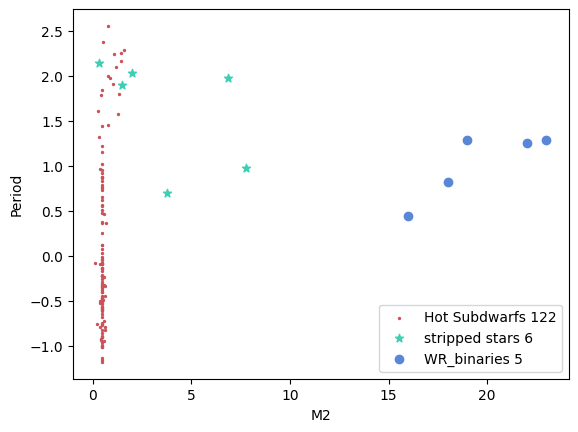

In [59]:

x_key = 'M2'
y_key = 'Period'

X_sdOB = to_triplet_array(hot_subdwarfs[x_key])[:,1]
Y_sdOB = np.log10(to_triplet_array(hot_subdwarfs[y_key])[:,1])
plt.scatter(X_sdOB, Y_sdOB, c = '#cc5159', s = 2,
            label = f'Hot Subdwarfs {np.sum(~np.isnan(X_sdOB)*~np.isnan(Y_sdOB))}')
            
X_stripS = to_triplet_array(stripped_stars[x_key])[:,1]
Y_stripS = np.log10(to_triplet_array(stripped_stars[y_key])[:,1])
plt.scatter(X_stripS, Y_stripS, c = '#3dceb4', marker = '*',
            label = f'stripped stars {np.sum(~np.isnan(X_stripS)*~np.isnan(Y_stripS))}')

X_WR = to_triplet_array(WR_binaries[x_key])[:,1]
Y_WR = np.log10(to_triplet_array(WR_binaries[y_key])[:,1])
plt.scatter(X_WR, Y_WR, c = '#5987d6',
            label = f'WR_binaries {np.sum(~np.isnan(X_WR) * ~np.isnan(Y_WR))}')

plt.xlabel(x_key)
plt.ylabel(y_key)
plt.legend(loc = 'lower right')
plt.savefig(PLOTS_DIR / "stripped_stars.png")
plt.show()




Unique categories in system_class:
['Blue straggler binary' 'Hot subdwarf' 'WR binary' 'Algol'
 'Chemically Peculiar' 'Gaia compact object'
 'Spectroscopic binary with dormant CO' 'Contact binary' 'pulsar binary'
 'post AGB' 'Stripped star' 'WD + MS' 'EL CVn']


NameError: name 'valid' is not defined

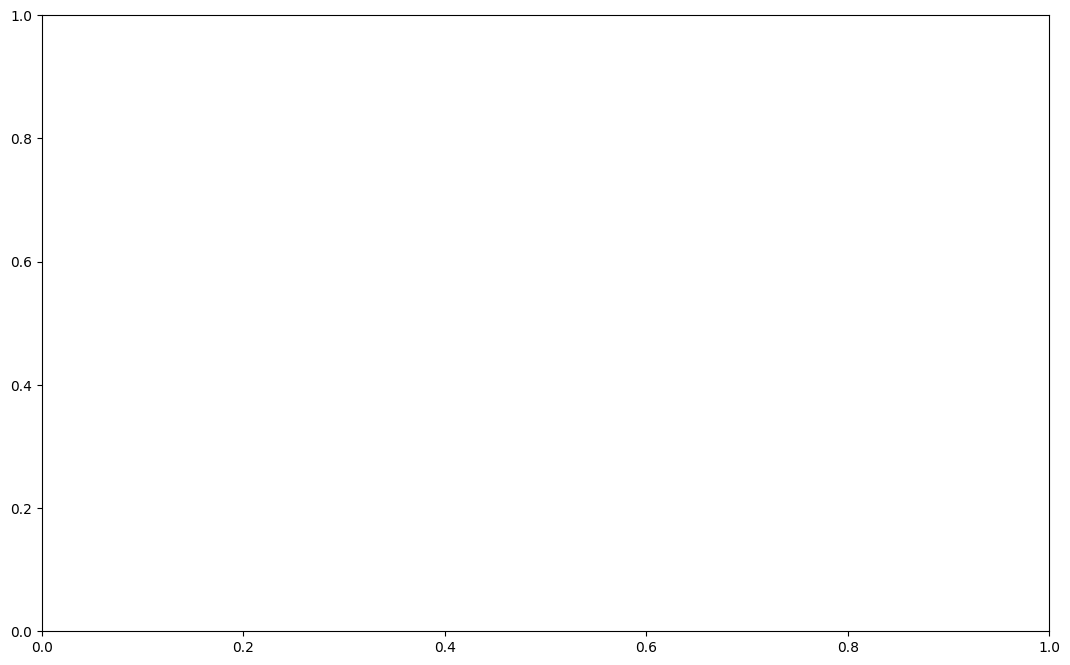

In [60]:
logx = True
logy = False

x_key = 'Period'
y_key = 'Eccentricity'
color_key = 'system_class'

table_to_plot = pd_catalog_data

# Get unique categories and create color mapping
unique_categories = table_to_plot[color_key].dropna().unique()
print(f"Unique categories in {color_key}:")
print(unique_categories)

# Define color palette - you can customize these colors
color_palette = plt.cm.tab20.colors  # Use matplotlib's tab20 colormap
color_map = {cat: color_palette[i % len(color_palette)] for i, cat in enumerate(sorted(unique_categories))}

# Map categories to colors
color_mapped = table_to_plot[color_key].map(color_map)

fig, ax = plt.subplots(figsize=(13, 8))

X_data = to_triplet_array(table_to_plot[x_key])[:,1]
Y_data = to_triplet_array(table_to_plot[y_key])[:,1]

# Plot each category separately for proper legend
for category in sorted(unique_categories):
    mask = table_to_plot[color_key] == category
    X_vals = to_triplet_array(table_to_plot.loc[mask, x_key])
    X_min, X_mid, X_max = X_vals[:,0], X_vals[:,1], X_vals[:,2]

    Y_vals = to_triplet_array(table_to_plot.loc[mask, y_key])
    Y_min, Y_mid, Y_max = Y_vals[:,0],Y_vals[:,1], Y_vals[:,2]
    
    # plt.scatter(X_mid, Y_mid) 
    #             c=[color_map[category]], 
    #             s=10,
    #             label=f'{category} ({np.sum(valid)})',
    #             alpha=0.7)
    ax.errorbar(X_mid, Y_mid, 
                xerr = (X_min, X_max),
                yerr = (Y_min, Y_max),
                c= color_map[category], 
                fmt='o',
                label=f'{category} ({np.sum(valid)})',
                alpha=0.7)

plt.xlabel(x_key, fontsize=12)
plt.ylabel(y_key, fontsize=12)
if logx:
    ax.set_xscale('log')
if logy:
    ax.set_yscale('log')

plt.legend(loc='best',bbox_to_anchor=(1.0, 1.), fontsize=10)
plt.title(f'{y_key} vs {x_key} colored by {color_key}', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"{y_key}_vs_{x_key}_by_{color_key}.png", dpi=150)
plt.show()

# Print the color mapping for reference
print("\nColor mapping:")
for cat, col in color_map.items():
    print(f"  {cat}: RGB{tuple(np.round(col[:3], 3))}")


In [61]:
# Example 1: Simple usage with automatic colors
fig = plotly_vars('Period', 'Eccentricity', pd_catalog_data, logx=True, color_by='system_class')
fig.show()


In [62]:
def is_number(x):
    return isinstance(x, (int, float)) and not np.isnan(x)


def extract_value_and_error(val):
    """
    Return (value, err_low, err_high)

    Rules:
    - None -> (None, None, None)
    - scalar number -> (value, None, None)
    - scalar non-number -> (value, None, None)
    - list:
        * if numeric triplet [min, max, adopted] -> compute errors
        * otherwise -> return last non-null element, no errors
    """
    if val is None:
        return None, None, None

    # Scalar
    if not isinstance(val, list):
        return val, None, None

    # List case
    # Keep non-null entries
    clean = [v for v in val if v is not None]
    if len(clean) == 0:
        return None, None, None

    # Try numeric [min, max, adopted]
    if (
        len(val) >= 3
        and is_number(val[0])
        and is_number(val[1])
        and is_number(val[2])
    ):
        vmin, vmax, vadopt = val[:3]
        err_low = vadopt - vmin if vmin is not None else None
        err_high = vmax - vadopt if vmax is not None else None
        return vadopt, err_low, err_high

    # Fallback: non-numeric list (strings, refs, methods, etc.)
    return clean[-1], None, None


In [63]:
def read_catalog(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)

    rows = []
    for entry in data:
        row = {}
        for key, val in entry.items():
            value, err_low, err_high = extract_value_and_error(val)
            row[key] = value
            row[f"{key}_err_low"] = err_low
            row[f"{key}_err_high"] = err_high
        rows.append(row)

    return pd.DataFrame(rows)


df = read_catalog(MAIN_CATALOG)

In [64]:
import numpy as np
import plotly.graph_objects as go

def plot_catalog(df, x, y, color_by="system_class", logx=False, logy=False):
    """
    Interactive scatter plot of a post-mass-transfer catalog.
    
    Parameters
    ----------
    df : pd.DataFrame
        Catalog dataframe with numeric columns and *_err_low / *_err_high
    x : str
        Column name for x-axis
    y : str
        Column name for y-axis
    color_by : str
        Column name to color points by
    logx, logy : bool
        Log scale axes
    """
    # Keep only rows with finite x and y
    mask = (
        df[x].notnull() & df[y].notnull() &
        np.isfinite(df[x]) & np.isfinite(df[y])
    )
    df_plot = df[mask].copy()

    # Count totals for legend
    total_counts = df[color_by].value_counts()
    plotted_counts = df_plot[color_by].value_counts()

    fig = go.Figure()

    # Add one trace per group
    for cls, group in df_plot.groupby(color_by):
        label = f"{cls} ({plotted_counts.get(cls,0)}/{total_counts.get(cls,0)})"

        fig.add_trace(
            go.Scatter(
                x=group[x],
                y=group[y],
                mode="markers",
                name=label,
                # Initially hide error bars; toggle via buttons
                error_x=dict(
                    type="data",
                    symmetric=False,
                    array=group.get(f"{x}_err_high"),
                    arrayminus=group.get(f"{x}_err_low"),
                    visible=False,
                ),
                error_y=dict(
                    type="data",
                    symmetric=False,
                    array=group.get(f"{y}_err_high"),
                    arrayminus=group.get(f"{y}_err_low"),
                    visible=False,
                ),
                customdata=np.stack(
                    [
                        group["System Name"],
                        group["Type1"],
                        group["Type2"],
                    ],
                    axis=-1,
                ),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>"
                    f"{x}: %{x}<br>"
                    f"{y}: %{y}<br>"
                    "Type1: %{customdata[1]}<br>"
                    "Type2: %{customdata[2]}<extra></extra>"
                ),
            )
        )

    # Add toggle buttons for errors
    n_traces = len(fig.data)
    fig.update_layout(
        template="simple_white",
        legend_title_text=color_by,
        width=900,   # width in pixels
        height=600,  # height in pixels
        xaxis_title=x,
        yaxis_title=y,
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.5,
                y=1.15,
                xanchor="center",
                buttons=[
                    dict(
                        label="Show errors",
                        method="update",
                        args=[{
                            "error_x.visible": [True]*n_traces,
                            "error_y.visible": [True]*n_traces,
                        }],
                    ),
                    dict(
                        label="Hide errors",
                        method="update",
                        args=[{
                            "error_x.visible": [False]*n_traces,
                            "error_y.visible": [False]*n_traces,
                        }],
                    ),
                ],
            )
        ]
    )

    # Log axes if requested
    if logx:
        fig.update_xaxes(type="log")
    if logy:
        fig.update_yaxes(type="log")

    fig.show()


In [65]:
plot_catalog(
    df,
    x="Period",
    y="Eccentricity",
    color_by="system_class",
    logx=True,
)


In [66]:
pd_catalog_data[['System Name', 'Reference','Period', 'Eccentricity', 'M1', 'M2' ]][pd_catalog_data['system_class'] == 'Blue straggler binary']

,System Name,Reference,Period,Eccentricity,M1,M2
0,Cl* NGC 188 PKM 451,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[4.0, 722.0, 4.0]","[0.03, 0.34, 0.03]","[None, None, None]","[None, None, None]"
1,Cl* NGC 188 PKM 1888,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[30.0, 2240.0, 30.0]","[0.04, 0.21, 0.04]","[None, None, None]","[None, None, None]"
2,Cl* NGC 188 PKM 2679,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[8.0, 1033.0, 8.0]","[0.05, 0.07, 0.05]","[None, None, None]","[None, None, None]"
3,Cl* NGC 188 PKM 4348,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[8.0, 1168.0, 8.0]","[0.05, 0.09, 0.05]","[None, None, None]","[None, None, None]"
4,Cl* NGC 188 PKM 4540,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[70.0, 3030.0, 70.0]","[0.07, 0.36, 0.07]","[None, None, None]","[None, None, None]"
5,Cl* NGC 188 PKM 4581,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[1.6, 546.7, 1.6]","[0.015, 0.269, 0.015]","[None, None, None]","[None, None, None]"
6,Cl* NGC 188 PKM 4589,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[1.7, 615.2, 1.7]","[0.04, 0.21, 0.04]","[None, None, None]","[None, None, None]"
7,Cl* NGC 188 PKM 4970,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[2.4, 1002.6, 2.4]","[0.013, 0.095, 0.013]","[None, None, None]","[None, None, None]"
8,Cl* NGC 188 PKM 5325,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[12.0, 1772.0, 12.0]","[0.03, 0.77, 0.03]","[None, None, None]","[None, None, None]"
9,Cl* NGC 188 PKM 5350,"[2009AJ....137.3743G, 2015ApJ...814..163G]","[3.0, 690.0, 3.0]","[0.05, 0.07, 0.05]","[None, None, None]","[None, None, None]"


In [67]:
pd_catalog_data[['System Name', 'Reference' ]][pd_catalog_data['system_class'] == 'Blue straggler binary']

,System Name,Reference
0,Cl* NGC 188 PKM 451,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
1,Cl* NGC 188 PKM 1888,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
2,Cl* NGC 188 PKM 2679,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
3,Cl* NGC 188 PKM 4348,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
4,Cl* NGC 188 PKM 4540,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
5,Cl* NGC 188 PKM 4581,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
6,Cl* NGC 188 PKM 4589,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
7,Cl* NGC 188 PKM 4970,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
8,Cl* NGC 188 PKM 5325,"[2009AJ....137.3743G, 2015ApJ...814..163G]"
9,Cl* NGC 188 PKM 5350,"[2009AJ....137.3743G, 2015ApJ...814..163G]"


In [68]:
# Count systems by class with nice formatting
print(f"Total systems in catalog: {len(pd_catalog_data)}")
print("\n" + "="*60)
print(f"{'System Class':<35} {'Count':>10}")
print("="*60)

# Get counts and sort by frequency (descending)
class_counts = [(cls, sum(pd_catalog_data['system_class'] == cls)) 
                for cls in np.unique(pd_catalog_data['system_class'])]
class_counts.sort(key=lambda x: x[1], reverse=True)

for sys_class, count in class_counts:
    print(f"{sys_class:<35} {count:>10,}")

print("="*60)
print(f"{'TOTAL':<35} {len(pd_catalog_data):>10,}")
print("="*60)

Total systems in catalog: 4451

System Class                             Count
WD + MS                                  3,909
Algol                                      126
Hot subdwarf                               123
Chemically Peculiar                         82
EL CVn                                      65
Spectroscopic binary with dormant CO         34
post AGB                                    33
Contact binary                              22
WR binary                                   19
Blue straggler binary                       17
Stripped star                                9
pulsar binary                                8
Gaia compact object                          4
TOTAL                                    4,451


In [69]:
# Filter out NaN values before checking unique source files
source_files = pd_catalog_data['source_file'].dropna()
print("Unique source files:")
# print(np.unique(source_files))

# Check if any systems have 'WDMS/' in their source_file
WD_MS_sys_bool = pd_catalog_data['source_file'].str.contains('WDMS/', na=False)
print(f"\nNumber of WDMS systems: {WD_MS_sys_bool.sum()}")

display(np.unique(pd_catalog_data['source_file'][WD_MS_sys_bool]))

Unique source files:

Number of WDMS systems: 3499


array(['WDMS/Escorza2019.h5', 'WDMS/RebassaMansergas2012.h5',
       'WDMS/Shahaf2024.h5', 'WDMS/WD_Binary_Pathways_VI.h5',
       'WDMS/WD_Binary_Pathways_X.h5', 'WDMS/Zorotovic2010.h5'],
      dtype=object)

In [70]:
# WDMS/RebassaMansergas2012.h5',
# WDMS/Shahaf2024.h5', 
# WDMS/Zorotovic2010.h5
# 'WDMS/WD_Binary_Pathways_VI.h5',
# 'WDMS/WD_Binary_Pathways_X.h5', 

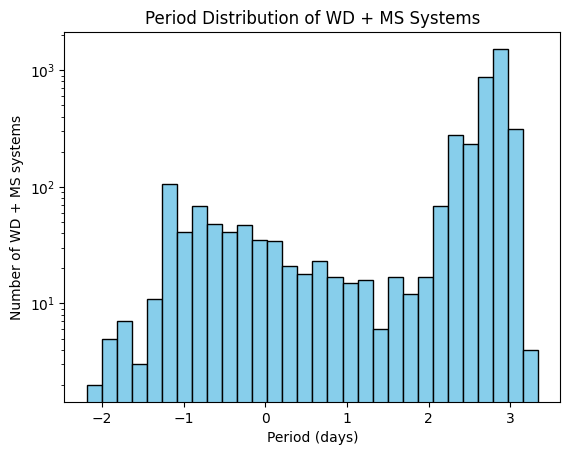

In [71]:
WD_MS_sys_class = pd_catalog_data['system_class'] == 'WD + MS'

logP = np.log10(to_triplet_array(pd_catalog_data['Period'][WD_MS_sys_class])[:,1])
plt.hist(logP, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Period (days)')
plt.ylabel('Number of WD + MS systems')
plt.title('Period Distribution of WD + MS Systems')
plt.yscale('log')
plt.savefig(PLOTS_DIR / "WD_MS_period_distribution.png", dpi=150  )
plt.show()



In [72]:
np.unique(pd_catalog_data['evol_type_2'].dropna())

array(['AGB', 'BH', 'HG', 'He-star', 'MS', 'NS', 'RGB', 'WD'],
      dtype=object)

In [73]:
(pd_catalog_data[['Reference', 'System Name', 'system_class', 'M1', 'M2', 'evol_type_1', 'evol_type_2', 'obs_type_1', 'obs_type_2', 'source_file']][pd_catalog_data['system_class'] == 'pulsar binary'])



,Reference,System Name,system_class,M1,M2,evol_type_1,evol_type_2,obs_type_1,obs_type_2,source_file
191,[1989Natur.340..367L],PSR B1820-11,pulsar binary,"[None, None, None]","[None, None, None]",MS,NS,MS/WD?,None,ns_table.h5
192,[2022ApJ...924..135P],PSR J1954+2529,pulsar binary,"[None, None, None]","[None, None, None]",MS,NS,MS/WD?,None,ns_table.h5
245,"[1995ApJ...447L.117B, 1996Natur.381..584K]",PSR J0045-7319,pulsar binary,"[1.8, 8.8, 1.8]","[None, 1.4, None]",MS,NS,BIV,None,young_psr_table.h5
246,[2014MNRAS.437.3255S],PSR B1259-63,pulsar binary,"[None, 20.0, None]","[None, 1.4, None]",MS,NS,Be,None,young_psr_table.h5
247,"[2011MNRAS.412L..63B, 2012MNRAS.425.2378M]",PSR J1638-4725,pulsar binary,"[4.0, 20.0, 6.0]","[None, 1.4, None]",MS,NS,B,None,young_psr_table.h5
248,[2017MNRAS.464.1211H],PSR J2032+4127,pulsar binary,"[None, 15.0, None]","[None, 1.35, None]",MS,NS,Be,None,young_psr_table.h5
249,[2023ApJ...943...57A],PSR J2108+4516,pulsar binary,"[2.75, 20.25, 2.75]","[None, 1.4, None]",MS,NS,O/Be,None,young_psr_table.h5
250,[2024A&A...682A.178V],PSR J0210+5845,pulsar binary,"[None, 3.6, None]","[None, 1.4, None]",MS,NS,B6V,None,young_psr_table.h5


In [74]:
(pd_catalog_data[['Reference', 'System Name']][pd_catalog_data['system_class'] == 'pulsar binary'])


,Reference,System Name
191,[1989Natur.340..367L],PSR B1820-11
192,[2022ApJ...924..135P],PSR J1954+2529
245,"[1995ApJ...447L.117B, 1996Natur.381..584K]",PSR J0045-7319
246,[2014MNRAS.437.3255S],PSR B1259-63
247,"[2011MNRAS.412L..63B, 2012MNRAS.425.2378M]",PSR J1638-4725
248,[2017MNRAS.464.1211H],PSR J2032+4127
249,[2023ApJ...943...57A],PSR J2108+4516
250,[2024A&A...682A.178V],PSR J0210+5845


In [75]:
pulsar_bool = ["Pulsar" in note for note in pd_catalog_data['Notes'].dropna() ] 
print(sum(pulsar_bool))
# display(pd_catalog_data[pulsar_bool] )

8
